# Set Up

In [1]:
import torch as nn 
import torch.nn as nn 
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import SGD
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd 
import numpy as np 

pd.set_option('display.max_columns', None)  # Show all columns in DataFrame display

In [2]:
MEAN_4_DAY_DATA_PATH = '../Data/CleanData/Trial_2_Mean_Sensor_FW_No_Lag.csv'
MEAN_4_DAY_DATA_PATH_LAG_1 = '../Data/CleanData/Trial_2_Mean_Sensor_FW_Lag_1.csv'
MEAN_4_DAY_DATA_PATH_LAG_2 = '../Data/CleanData/Trial_2_Mean_Sensor_FW_Lag_2.csv'

def load_mean_4_day_data(path=MEAN_4_DAY_DATA_PATH):

    df = pd.read_csv(path)
    return df

def load_mean_4_day_data_lag_1(path=MEAN_4_DAY_DATA_PATH_LAG_1):

    df = pd.read_csv(path)
    return df

def load_mean_4_day_data_lag_2(path=MEAN_4_DAY_DATA_PATH_LAG_2):

    df = pd.read_csv(path)
    return df

# Neural Network 5 (model5)
* Preprocessing: Standardized features 
* Model: Basic feedforward NN with 1 hidden layer (32 neurons, ReLU activation)
* Adam optimizer, MSE loss
* Hyperparameters:
  * Adam optimizer
  * MSE Loss 
  * Hidden layer size: 32
  * Learning rate: 0.01
  * Epochs: 100
  * Used 5-fold cross-validation to select hyperparameters
* Evaluation: Final test loss (MSE and RMSE)

Features: 
  * carbon_dioxide
  * temp_env
  * humidity
  * pressure
  * electrical_conductivity
  * volume
  * temp_nutr
  * volume_flow_rate


Target: total_fresh_weight_g

In [3]:
load_mean_4_day_data()

,day,plant_id,total_fresh_weight_g,fw_change_g,carbon_dioxide,electrical_conductivity,temp_env,temp_nutr,humidity,pressure
0,0.0,1.0,29.7,0.0,0.323495,1437.553398,20.285433,22.909825,83.790346,795.159839
1,0.0,2.0,30.1,0.0,0.323495,1437.553398,20.285433,22.909825,83.790346,795.159839
2,0.0,3.0,31.8,0.0,0.323495,1437.553398,20.285433,22.909825,83.790346,795.159839
3,0.0,4.0,29.3,0.0,0.323495,1437.553398,20.285433,22.909825,83.790346,795.159839
4,0.0,5.0,30.2,0.0,0.323495,1437.553398,20.285433,22.909825,83.790346,795.159839
...,...,...,...,...,...,...,...,...,...,...
75,28.0,6.0,211.0,66.0,546.282779,1446.892368,21.491528,21.611981,77.851267,621.142045
76,28.0,7.0,188.0,53.0,546.282779,1446.892368,21.491528,21.611981,77.851267,621.142045
77,28.0,8.0,215.0,57.0,546.282779,1446.892368,21.491528,21.611981,77.851267,621.142045
78,28.0,9.0,198.0,71.0,546.282779,1446.892368,21.491528,21.611981,77.851267,621.142045


Fold [1/5], Final Val Loss (MSE): 25.9534, Final Val RMSE: 5.0944


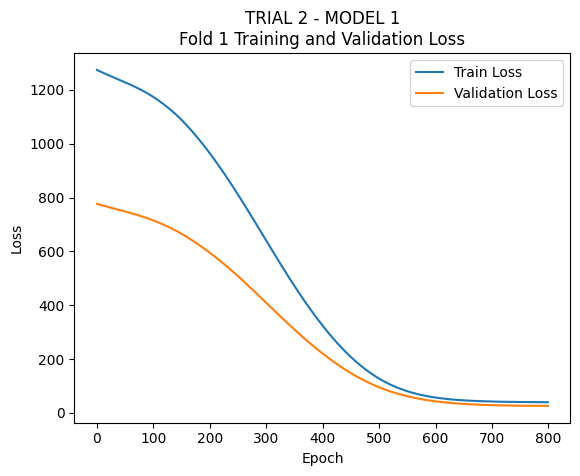

Fold [2/5], Final Val Loss (MSE): 51.9368, Final Val RMSE: 7.2067


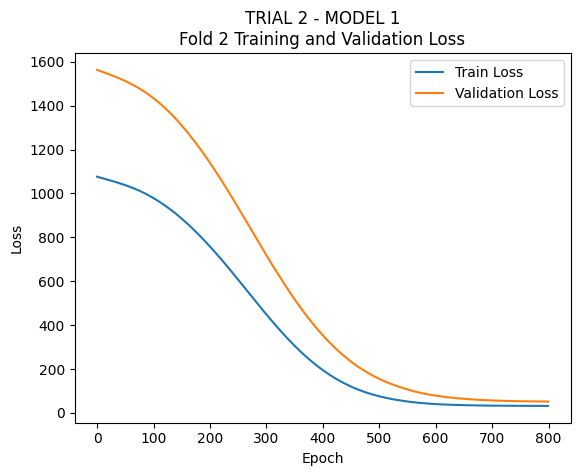

Fold [3/5], Final Val Loss (MSE): 9.2109, Final Val RMSE: 3.0349


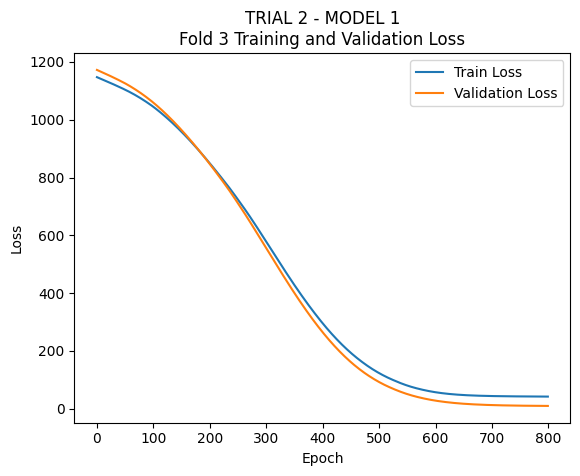

Fold [4/5], Final Val Loss (MSE): 104.9367, Final Val RMSE: 10.2439


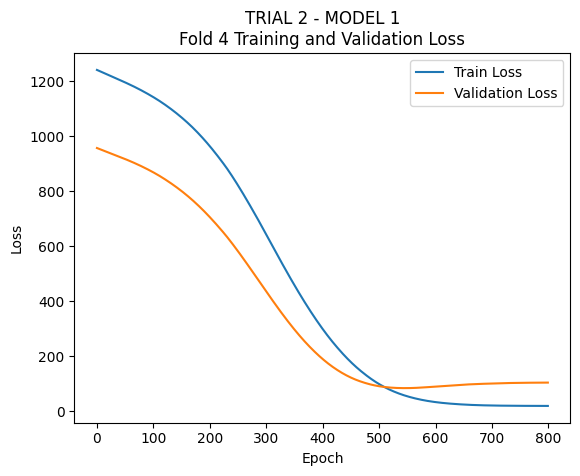

Fold [5/5], Final Val Loss (MSE): 32.1961, Final Val RMSE: 5.6742


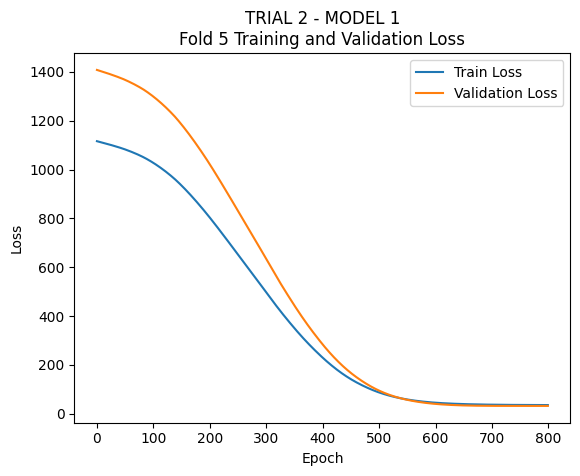


Mean CV Val Loss (MSE): 44.8468
Mean CV Val Loss (RMSE): 6.6968
Std CV Val Loss (MSE): 33.0090
Std CV Val Loss (RMSE): 5.7453


In [4]:

# load data 

import torch


df = (load_mean_4_day_data())
df = df[df['day'] > 0].reset_index(drop=True) # drop day zero
columns_to_drop = ['day', 'plant_id', 'total_fresh_weight_g'] # drop columns not needed for modeling
df = df.drop(columns=columns_to_drop)

target_col = 'fw_change_g'

X = df.drop(columns=[target_col]).to_numpy(dtype=np.float32)
y = df[target_col].to_numpy(dtype=np.float32)

feature_names = df.drop(columns=[target_col]).columns.tolist()

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#### Neural Network Model
class BasicNN(nn.Module): # inherits from Module
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__() # call initialization from module
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x
    
# pick manual seed
torch.manual_seed(42)

# hyperparameters    
input_size = X_train.shape[1]
hidden_size = 32
output_size = 1
learning_rate = .001
num_epochs = 800

# loss function
criterion = nn.MSELoss()

# cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_val_losses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    
    X_train_fold = X_train[train_idx]
    y_train_fold = y_train[train_idx]
    X_val_fold = X_train[val_idx]
    y_val_fold = y_train[val_idx]
    
    # standardize within each fold
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold).astype(np.float32)
    X_val_fold = scaler.transform(X_val_fold).astype(np.float32)
    
    # convert to tensors
    X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32).view(-1, 1)
    X_val_tensor = torch.tensor(X_val_fold, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val_fold, dtype=torch.float32).view(-1, 1)
    
    # initialize model
    model = BasicNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # train
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        model.train()
        outputs = model(X_train_tensor) # get predicted results
        loss = criterion(outputs, y_train_tensor) 
        optimizer.zero_grad() 
        loss.backward() # compute gradients
        optimizer.step() # update weights
        
        train_losses.append(loss.item())
        
        # validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            val_loss = criterion(val_outputs, y_val_tensor)
        
        val_losses.append(val_loss.item())
    
    cv_val_losses.append(val_losses[-1])
    
    print(f"Fold [{fold+1}/5], Final Val Loss (MSE): {val_losses[-1]:.4f}, Final Val RMSE: {np.sqrt(val_losses[-1]):.4f}")
    
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"TRIAL 2 - MODEL 1\nFold {fold+1} Training and Validation Loss")
    plt.legend()
    plt.savefig(f'../Figures/T2_Model_1_fold_{fold+1}_training_validation_loss.png')
    plt.show()

print(f"\nMean CV Val Loss (MSE): {np.mean(cv_val_losses):.4f}")
print(f"Mean CV Val Loss (RMSE): {np.sqrt(np.mean(cv_val_losses)):.4f}")
print(f"Std CV Val Loss (MSE): {np.std(cv_val_losses):.4f}")
print(f"Std CV Val Loss (RMSE): {np.sqrt(np.std(cv_val_losses)):.4f}")



Epoch [1/800], Train Loss: 1168.0280
Epoch [2/800], Train Loss: 1167.0686
Epoch [3/800], Train Loss: 1166.1124
Epoch [4/800], Train Loss: 1165.1593
Epoch [5/800], Train Loss: 1164.2102
Epoch [6/800], Train Loss: 1163.2675
Epoch [7/800], Train Loss: 1162.3281
Epoch [8/800], Train Loss: 1161.3915
Epoch [9/800], Train Loss: 1160.4574
Epoch [10/800], Train Loss: 1159.5333
Epoch [11/800], Train Loss: 1158.6215
Epoch [12/800], Train Loss: 1157.7142
Epoch [13/800], Train Loss: 1156.8263
Epoch [14/800], Train Loss: 1155.9425
Epoch [15/800], Train Loss: 1155.0602
Epoch [16/800], Train Loss: 1154.1796
Epoch [17/800], Train Loss: 1153.3005
Epoch [18/800], Train Loss: 1152.4227
Epoch [19/800], Train Loss: 1151.5465
Epoch [20/800], Train Loss: 1150.6714
Epoch [21/800], Train Loss: 1149.7975
Epoch [22/800], Train Loss: 1148.9249
Epoch [23/800], Train Loss: 1148.0560
Epoch [24/800], Train Loss: 1147.1877
Epoch [25/800], Train Loss: 1146.3203
Epoch [26/800], Train Loss: 1145.4532
Epoch [27/800], Train

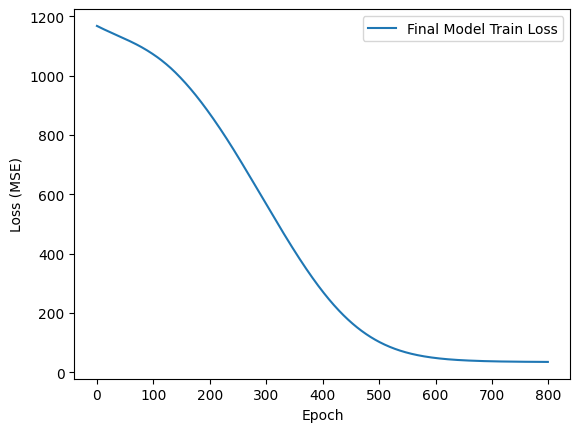

In [5]:
# train final model on full training set

# hyperparameters    
input_size = X_train.shape[1]
hidden_size = 32
output_size = 1
learning_rate = .001
num_epochs = 800

# standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

# convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# initialize model
torch.manual_seed(42)
model1 = BasicNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)
optimizer = optim.Adam(model1.parameters(), lr=learning_rate)

# train final model and store training loss
train_losses = []

for epoch in range(num_epochs):
    model1.train()
    outputs = model1(X_train_tensor) # get predicted results
    loss = criterion(outputs, y_train_tensor) 
    optimizer.zero_grad() 
    loss.backward() # compute gradients
    optimizer.step() # update weights

    train_losses.append(loss.item())

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}")

# final test evaluation
model1.eval()
with torch.no_grad():
    test_outputs = model1(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)

print(f"\nFinal Test Loss (MSE): {test_loss.item():.4f}")
print(f"Final Test Loss (RMSE): {np.sqrt(test_loss.item()):.4f}")

plt.plot(train_losses, label="Final Model Train Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.savefig('../Figures/T2_Model_1_final_training_loss.png')
plt.show()

## Permutation Feature Importance (model1)
* Compute RMSE increase when each feature is randomly shuffled in the test set
* Repeated 20 times and computed average RMSE increase for each feature

Baseline RMSE: 6.036469

Permutation results (20-repeat average):
temp_nutr                  RMSE=17.5329  (Δ=+11.4964,  sd=3.4210)
pressure                   RMSE=9.8229  (Δ=+3.7864,  sd=2.3363)
humidity                   RMSE=9.3882  (Δ=+3.3517,  sd=2.0604)
temp_env                   RMSE=7.9274  (Δ=+1.8910,  sd=1.4223)
carbon_dioxide             RMSE=7.8137  (Δ=+1.7773,  sd=0.8369)
electrical_conductivity    RMSE=6.5040  (Δ=+0.4675,  sd=1.7317)


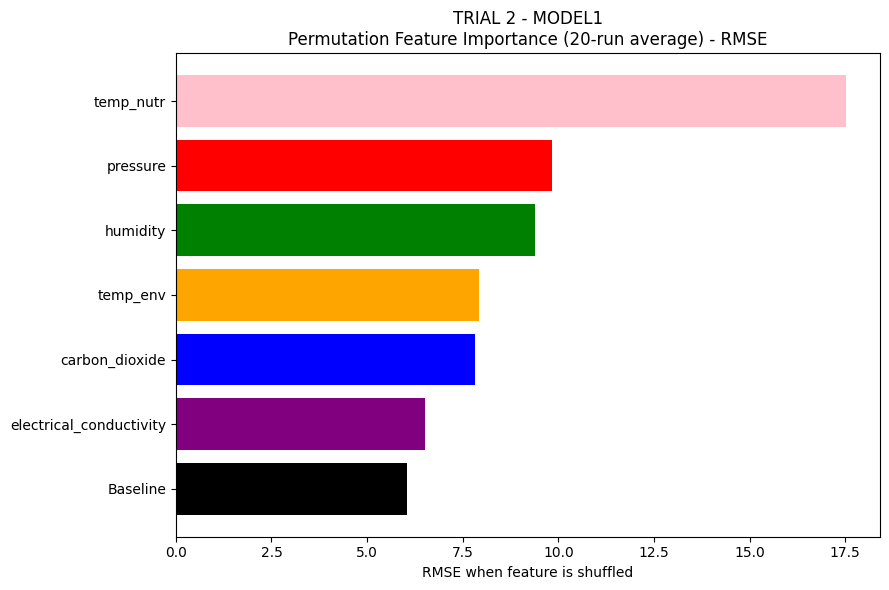

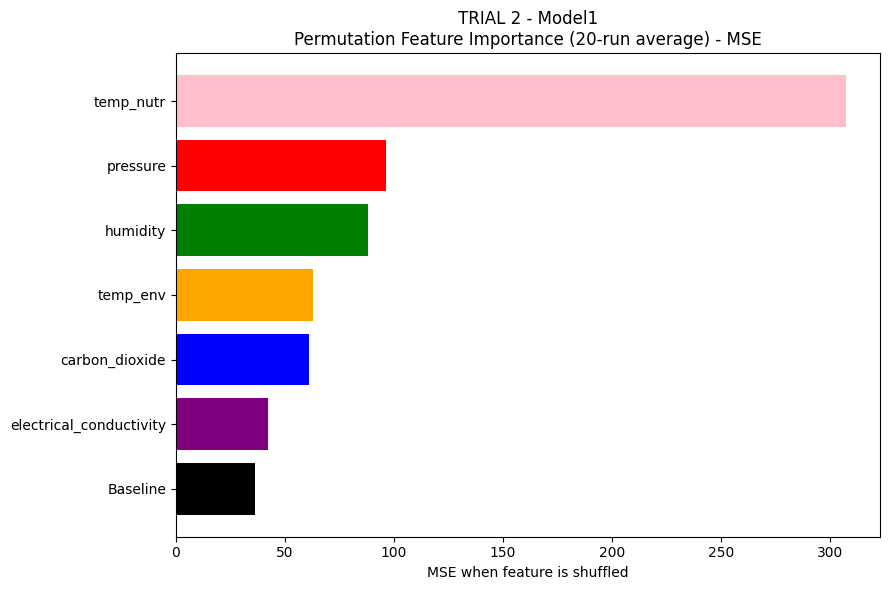

In [6]:
import numpy as np
import torch
import random
import matplotlib.pyplot as plt

# ==============================
# RMSE function
# ==============================
def rmse(y_pred, y_true):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

model1.eval()

# ==============================
# Baseline RMSE
# ==============================
with torch.no_grad():
    base_preds = model1(X_test_tensor).cpu().numpy()

y_true = y_test_tensor.cpu().numpy()
base_rmse = rmse(base_preds, y_true)

# ==============================
# Permutation Importance (20 repeats)
# ==============================
repeats = 20
perm_results = []
torch.manual_seed(42)

X_test_base = X_test_tensor.clone()
N = X_test_base.shape[0]

for j, name in enumerate(feature_names):
    rmses = []

    for r in range(repeats):
        X_perm = X_test_base.clone()

        # shuffle feature j
        idx = torch.randperm(N)
        X_perm[:, j] = X_perm[idx, j]

        with torch.no_grad():
            preds = model1(X_perm).cpu().numpy()

        rmses.append(rmse(preds, y_true))

    avg_perm_rmse = np.mean(rmses)
    std_perm_rmse = np.std(rmses)

    perm_results.append((name, avg_perm_rmse, std_perm_rmse))

# Sort by average permuted RMSE (largest first)
perm_results.sort(key=lambda x: x[1], reverse=True)

# ==============================
# Print results
# ==============================
print("Baseline RMSE:", round(base_rmse, 6))
print("\nPermutation results (20-repeat average):")

for name, avg_rmse, std_rmse in perm_results:
    delta = avg_rmse - base_rmse
    print(f"{name:25s}  RMSE={avg_rmse:.4f}  (Δ={delta:+.4f},  sd={std_rmse:.4f})")

# ==============================
# Plot
# ==============================

coef_colors = {
    'carbon_dioxide': 'blue',
    'temp_env': 'orange',
    'humidity': 'green',
    'pressure': 'red',
    'electrical_conductivity': 'purple',
    'volume': 'brown',
    'temp_nutr': 'pink',
    'volume_flow_rate': 'gray',
    'weight_lag_1': 'cyan',
    'weight_lag_2': 'magenta'
}

baseline_color = "black"

names = [n for n, _, _ in perm_results]
rmses = [r for _, r, _ in perm_results]
colors = [coef_colors.get(name, 'black') for name in names]

# Add baseline as separate bar
names_plot = names + ["Baseline"]
rmses_plot = rmses + [base_rmse]
colors_plot = colors + [baseline_color]

plt.figure(figsize=(9, 6))
plt.barh(names_plot[::-1], rmses_plot[::-1], color=colors_plot[::-1])

plt.xlabel("RMSE when feature is shuffled")
plt.title("TRIAL 2 - MODEL1\nPermutation Feature Importance (20-run average) - RMSE")
plt.tight_layout()

plt.savefig('../Figures/t2_nn_model1_permutation_importance_rmse.png', bbox_inches='tight')
plt.show()

# plot for mse instead of rmse
plt.figure(figsize=(9, 6))
plt.barh(names_plot[::-1], [r**2 for r in rmses_plot][::-1], color=colors_plot[::-1])
plt.xlabel("MSE when feature is shuffled")
plt.title("TRIAL 2 - Model1\nPermutation Feature Importance (20-run average) - MSE")
plt.tight_layout()
plt.savefig('../Figures/t2_nn_model1_permutation_importance_mse.png', bbox_inches='tight')
plt.show()

## Interactions (partial dependence plots - trial 2 model 1)

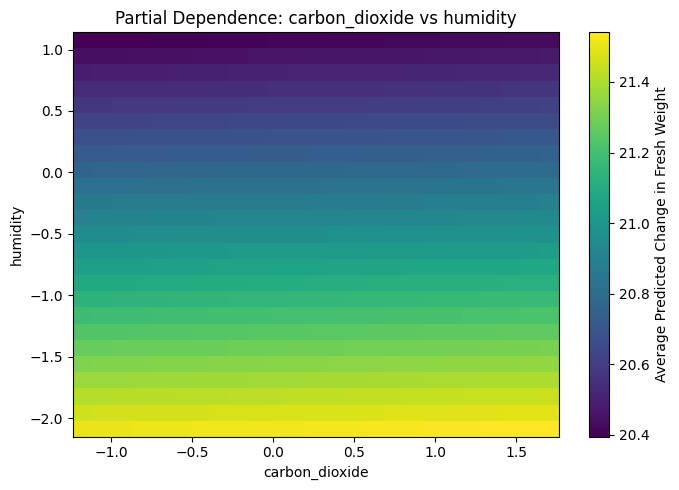

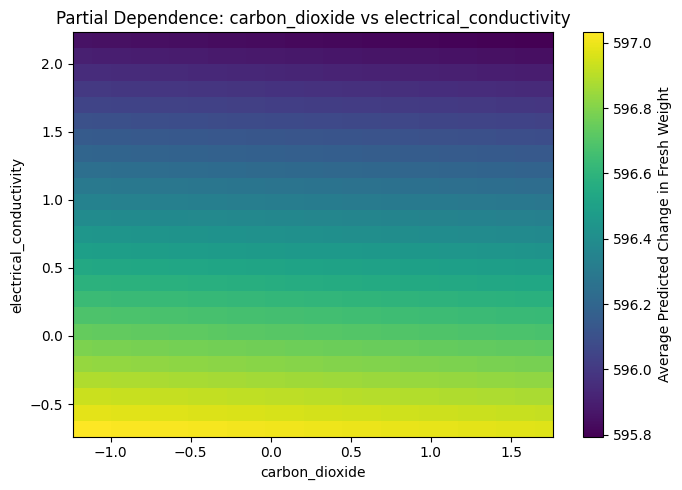

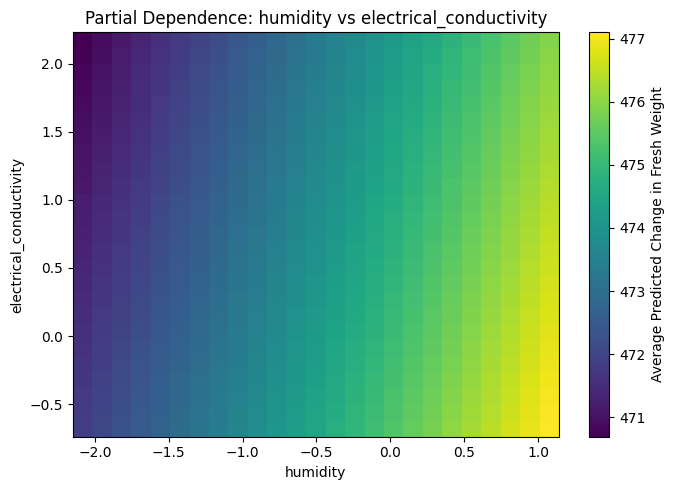

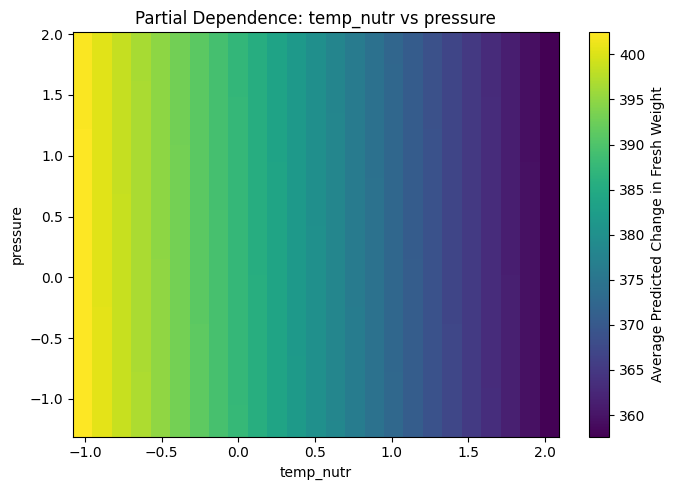

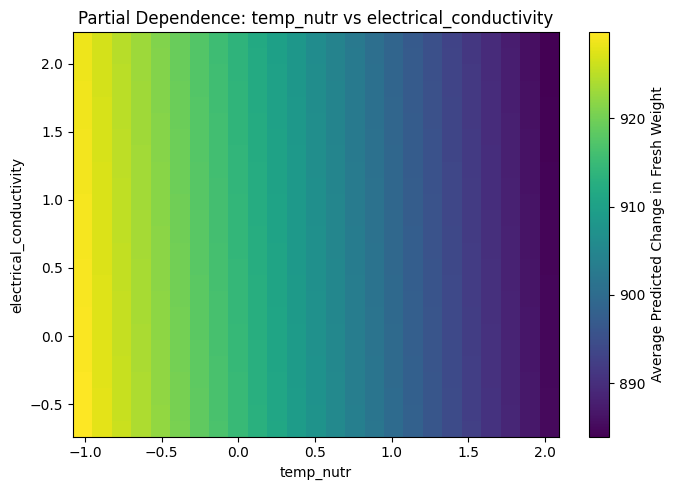

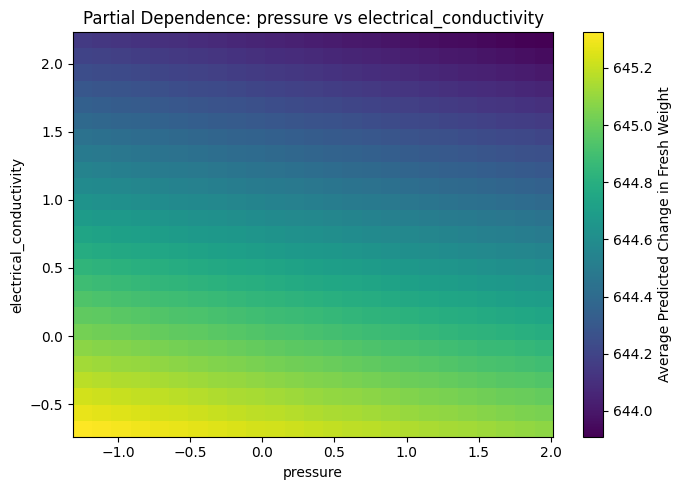

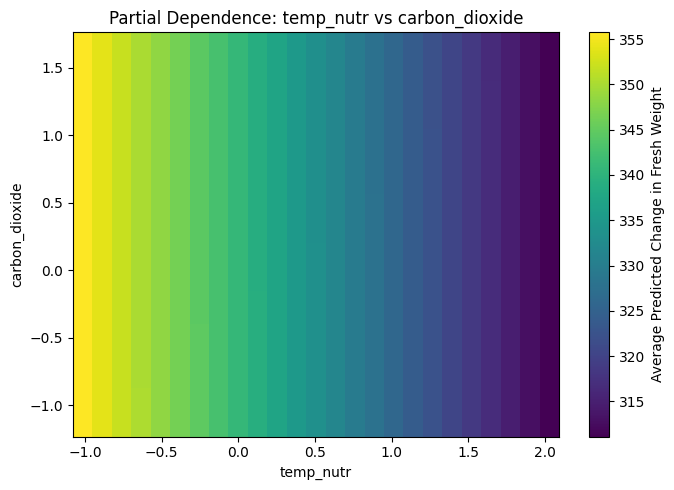

In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# make sure model is in eval mode
model1.eval()

# feature pairs to examine
feature_pairs = [
    ("carbon_dioxide", "humidity"),
    ("carbon_dioxide", "electrical_conductivity"),
    ("humidity", "electrical_conductivity"),
    ("temp_nutr", "pressure"),
    ("temp_nutr", "electrical_conductivity"),
    ("pressure", "electrical_conductivity"),
    ("temp_nutr", "carbon_dioxide"),
]

# map feature names to column indices
name_to_idx = {name: i for i, name in enumerate(feature_names)}

# use the ORIGINAL unscaled training data to define realistic value ranges
# and use the SCALED test tensor as the base data that gets modified
X_reference = X_test_tensor.clone()

grid_size = 25

for feat1, feat2 in feature_pairs:
    idx1 = name_to_idx[feat1]
    idx2 = name_to_idx[feat2]
    
    # grid in original feature units
    vals1_raw = np.linspace(X_train[:, idx1].min(), X_train[:, idx1].max(), grid_size)
    vals2_raw = np.linspace(X_train[:, idx2].min(), X_train[:, idx2].max(), grid_size)
    
    pdp = np.zeros((grid_size, grid_size))
    
    for i, v1_raw in enumerate(vals1_raw):
        for j, v2_raw in enumerate(vals2_raw):
            X_temp = X_reference.clone()
            
            # standardize using the fitted scaler from final model training
            v1_scaled = (v1_raw - scaler.mean_[idx1]) / scaler.scale_[idx1]
            v2_scaled = (v2_raw - scaler.mean_[idx2]) / scaler.scale_[idx2]
            
            X_temp[:, idx1] = v1_scaled
            X_temp[:, idx2] = v2_scaled
            
            with torch.no_grad():
                preds = model1(X_temp).cpu().numpy()
            
            pdp[j, i] = preds.mean()
    
    plt.figure(figsize=(7, 5))
    plt.imshow(
        pdp,
        origin="lower",
        aspect="auto",
        extent=[vals1_raw.min(), vals1_raw.max(), vals2_raw.min(), vals2_raw.max()]
    )
    plt.colorbar(label="Average Predicted Change in Fresh Weight")
    plt.xlabel(feat1)
    plt.ylabel(feat2)
    plt.title(f"Partial Dependence: {feat1} vs {feat2}")
    plt.tight_layout()
    plt.savefig(f"../Figures/t2_m1_pdp_{feat1}_{feat2}.png", bbox_inches="tight")
    plt.show()

## Perturbation Analysis (model1)

In [8]:
# baseline predictions

# fucntion that returns list of predictions after feature perturbation
def get_perturbed_predictions(model, X_test_tensor, feature_name, perturbation=0.1):
    with torch.no_grad():
        baseline_preds = model(X_test_tensor)

        X_perturbed = X_test_tensor.clone()
        X_perturbed[:, feature_names.index(feature_name)] *= (1 + perturbation)

        perturbed_preds = model(X_perturbed)

    return baseline_preds, perturbed_preds


get_perturbed_predictions(model1, X_test_tensor, 'electrical_conductivity', perturbation=0.1)


perturbation_results = []

for feature in feature_names:

    baseline_preds, perturbed_plus_10 = get_perturbed_predictions(
        model1, X_test_tensor, feature, perturbation=0.1
    )

    _, perturbed_minus_10 = get_perturbed_predictions(
        model1, X_test_tensor, feature, perturbation=-0.1
    )

    _, perturbed_plus_20 = get_perturbed_predictions(
        model1, X_test_tensor, feature, perturbation=0.2
    )

    _, perturbed_minus_20 = get_perturbed_predictions(
        model1, X_test_tensor, feature, perturbation=-0.2
    )

    _, perturbed_plus_50 = get_perturbed_predictions(
        model1, X_test_tensor, feature, perturbation=0.5
    )

    _, perturbed_minus_50 = get_perturbed_predictions(
        model1, X_test_tensor, feature, perturbation=-0.5
    )

    _, perturbed_plus_80 = get_perturbed_predictions(
        model1, X_test_tensor, feature, perturbation=0.8
    )

    _, perturbed_minus_80 = get_perturbed_predictions(
        model1, X_test_tensor, feature, perturbation=-0.8
    )

    plus_10_effect = (perturbed_plus_10 - baseline_preds).mean().item()
    minus_10_effect = (perturbed_minus_10 - baseline_preds).mean().item()
    plus_20_effect = (perturbed_plus_20 - baseline_preds).mean().item()
    minus_20_effect = (perturbed_minus_20 - baseline_preds).mean().item()
    plus_50_effect = (perturbed_plus_50 - baseline_preds).mean().item()
    minus_50_effect = (perturbed_minus_50 - baseline_preds).mean().item()
    plus_80_effect = (perturbed_plus_80 - baseline_preds).mean().item()
    minus_80_effect = (perturbed_minus_80 - baseline_preds).mean().item()

    perturbation_results.append({
        "feature": feature,
        "+10% effect (g)": plus_10_effect,
        "-10% effect (g)": minus_10_effect,
        "+20% effect (g)": plus_20_effect,
        "-20% effect (g)": minus_20_effect,
        "+50% effect (g)": plus_50_effect,
        "-50% effect (g)": minus_50_effect,
        "+80% effect (g)": plus_80_effect,
        "-80% effect (g)": minus_80_effect
    })

perturbation_df = pd.DataFrame(perturbation_results)

perturbation_df = perturbation_df.sort_values(
    by="+10% effect (g)",
    key=lambda x: x.abs(),
    ascending=False
).reset_index(drop=True)

perturbation_df = perturbation_df.round(4)

perturbation_df

,feature,+10% effect (g),-10% effect (g),+20% effect (g),-20% effect (g),+50% effect (g),-50% effect (g),+80% effect (g),-80% effect (g)
0,temp_env,0.3713,-0.3521,0.7427,-0.7028,1.8551,-1.7121,2.9682,-2.6786
1,carbon_dioxide,0.3479,-0.3279,0.7029,-0.6360,1.7697,-1.5235,2.8368,-2.3447
2,humidity,0.3299,-0.3074,0.6592,-0.6102,1.6451,-1.4692,2.6336,-2.2855
3,electrical_conductivity,0.2686,-0.2401,0.5370,-0.4640,1.3417,-1.0728,2.1566,-1.6542
4,temp_nutr,-0.2654,0.4729,-0.4651,0.9456,-0.5947,2.4855,-0.3508,4.0307
5,pressure,0.1719,-0.1673,0.3436,-0.3341,0.8586,-0.8022,1.3789,-1.2474


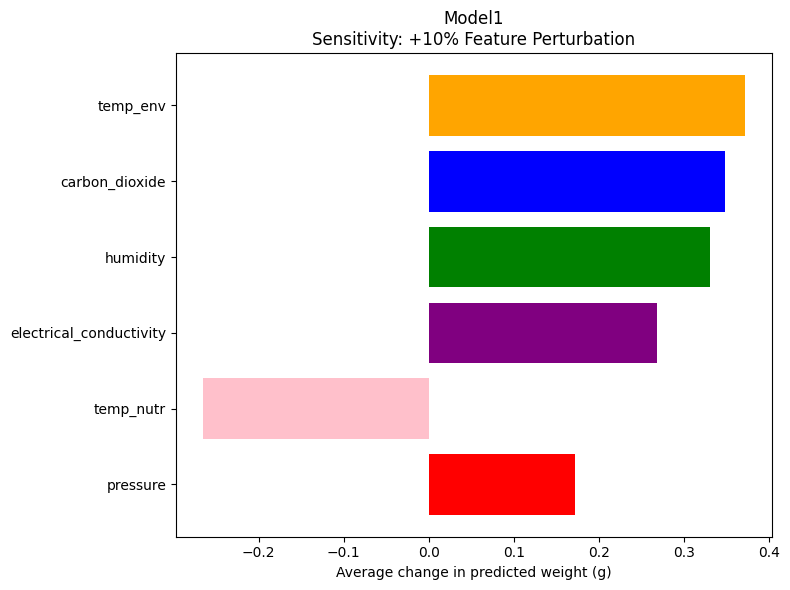

In [9]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

# map feature colors
colors = perturbation_df["feature"].map(coef_colors)

plt.figure(figsize=(8,6))

plt.barh(
    perturbation_df["feature"],
    perturbation_df["+10% effect (g)"],
    color=colors
)

plt.xlabel("Average change in predicted weight (g)")
plt.title("Model1\nSensitivity: +10% Feature Perturbation")

plt.gca().invert_yaxis()  # most important feature at top

plt.tight_layout()
plt.show()